В цьому домашньому завданні ми проведемо додаткові експерименти для рішення задачі бінарної класифікації і створимо ваш новий submission на змагання на Kaggle.

-----------


**Завдання 0**. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle)  Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").


**Завдання 1**. **Збираємо весь код з попереднього ДЗ в одному місці.** В лекційному ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb` ми познайомились з поняттям пайплайнів, а також я показала, як компактно виглядає рішення МЛ задачі, якщо ми зберемо весь код разом.

Оскільки ми далі будемо робити експерименти, які включають ті самі етапи попередньої обробки, але інше моделювання - буде зручно мати весь код компактно і під рукою. Тому зараз ми займемось збором коду до купи :) Після цього завдання для подальших експериментів ви можете перенести частини розвʼязку взагалі в окремий `.py` файл, аби було зручно імпортувати функції.

Зі свого рішення в попередньому домашньому завданні (`Логістична регресія з scikit learn.ipynb`) зберіть усі кроки розвʼязку задачі разом з використанням `sklearn.Pipeline` за прикладом з лекції.

Ваш код нижче має містити
1. Читання даних з файлу (поза пайплайном).
2. Розбиття на тренувальний і валідаційний набори, де валідаційний містить 20% даних (поза пайплайном).
3. Виділення категоріальних і числових колонок (поза пайплайном).
4. Підготовку категоріальних і числових колонок (частина пайплайну). В прикладі в лекції ми оформлювали обробку числових і категоріальних колонок в окремі трансформери `numeric_transformer`, `categorical_cols`. Рекоемндую зробити саме так, так потім зручніше вносити зміни :)
5. Тренування лог регресії (частина пайплайну).
6. Запуск пайплайну на тренування на трен. даних (поза пайплайном).
7. Запуск пайплайну на передбачення на трен і вал. даних і вимір метрик якості ROC-AUC + вивдення Confusion Matrix (поза пайплайном).
8. Збереження моделі в формат joblib (поза пайплайном).

Ви це все вже зробили в попереднтьому ДЗ! Тож, тут просто заадча все зібрати разом.

Нижче я додала підказки, що покроково ви маєте зробити. Якщо ви почуваєтесь впевнено, можете видалити ці підказки і реалізувати все самостійно, або ж - просто заповнити пропуски.

Завдання оцінюється в 10 балів. Головний результат - аби код в фіналі був робочий. Бо за не робочий нам гроші ніхто не заплатить :)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso, Ridge, ElasticNet

Area under ROC score on Train dataset: 0.88%


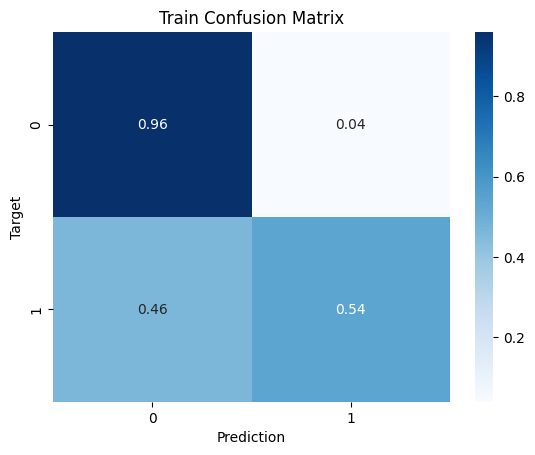

Area under ROC score on Validation dataset: 0.88%


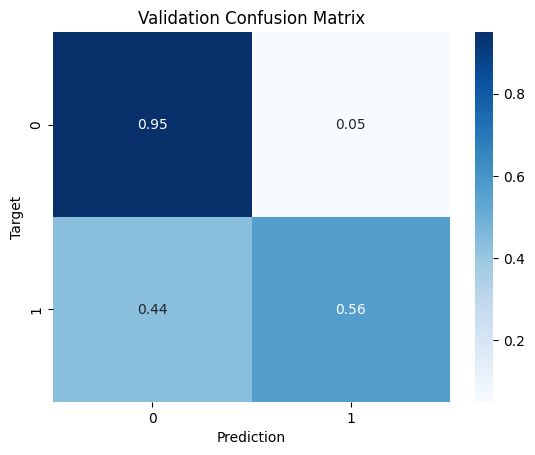

['/content/drive/MyDrive/Colab Notebooks/logistic_regression_pipeline.joblib']

In [4]:
raw_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/train.csv', index_col=0)

train_df, val_df = train_test_split(
    raw_df,
    test_size=0.2,
    random_state=42,
    stratify=raw_df['Exited']
)

# Створюємо трен. і вал. набори
target_col = 'Exited'
input_cols = [col for col in train_df.columns if col != target_col and col not in ['CustomerId', 'Surname']]

train_inputs = train_df[input_cols]
train_targets = train_df[target_col]
val_inputs = val_df[input_cols]
val_targets = val_df[target_col]

# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes(include=['number']).columns.tolist()
categorical_cols = train_inputs.select_dtypes(include=['object']).columns.tolist()

# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42))
])

# Тренуємо пайплайн
model_pipeline.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)
    probs = model_pipeline.predict_proba(inputs)[:, 1]
    roc_auc = roc_auc_score(targets, probs)
    print(f"Area under ROC score on {name} dataset: {roc_auc:.2f}%")
    confusion_matrix_ = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds

# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline, train_inputs, train_targets, 'Train')
val_preds = predict_and_plot(model_pipeline, val_inputs, val_targets, 'Validation')

# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline, '/content/drive/MyDrive/Colab Notebooks/logistic_regression_pipeline.joblib')

**Завдання 2**. Такс, у нас з вами є вже готовий пайплайн. Давайте проведемо нові експерименти.

  Додайте в попередню обробку числових колонок генерацію polinomal features до степені 2 включно. Для цього створіть новий препроцесор і створіть новий пайплайн.

  Запустіть пайплайн на тренування і виведіть метрики для тренувального і валідаційного набору. Напишіть, як вам модель? Чи спостерігається в цій моделі overfit чи underfit? Чи ця модель добре генералізує?

Area under ROC score on Train Poly2 dataset: 0.91%


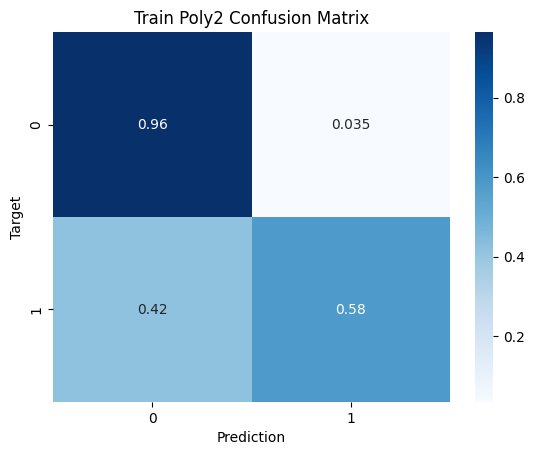

Area under ROC score on Validation Poly2 dataset: 0.91%


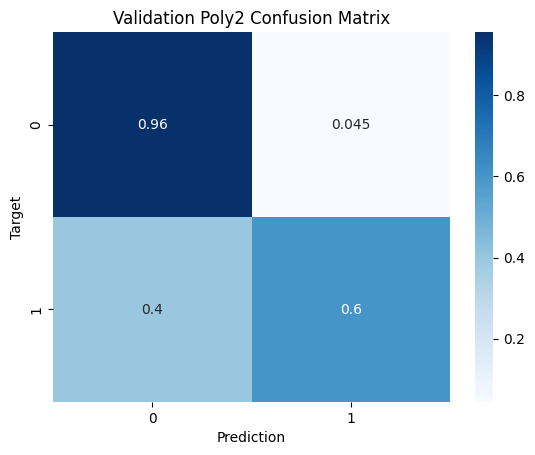

In [6]:
numeric_transformer_poly = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', MinMaxScaler())
])

preprocessor_poly2 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

pipeline_poly2 = Pipeline(steps=[
    ('preprocessor', preprocessor_poly2),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42))
])

pipeline_poly2.fit(train_inputs, train_targets)

train_preds_poly2 = predict_and_plot(pipeline_poly2, train_inputs, train_targets, 'Train Poly2')
val_preds_poly2 = predict_and_plot(pipeline_poly2, val_inputs, val_targets, 'Validation Poly2')

Модель стала кращою ніж у Завданні 1. Має гарну генералізацію.

**Завдання 3**. Тепер давайте створимо ще новий пайплайн, тільки тепер поліноміальні ознаки згенеруємо до степені 4. Зробіть висновок про якість моделі. Якщо вам подобається резульат якоїсь з моделей в цьому ДЗ - рекомендую зробити submission в змаганні.

Area under ROC score on Train Poly4 dataset: 0.93%


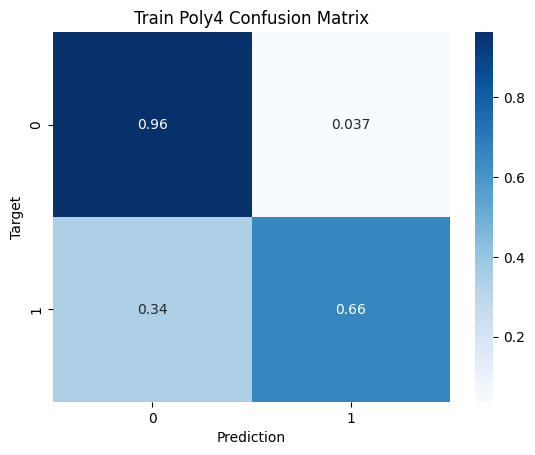

Area under ROC score on Validation Poly4 dataset: 0.93%


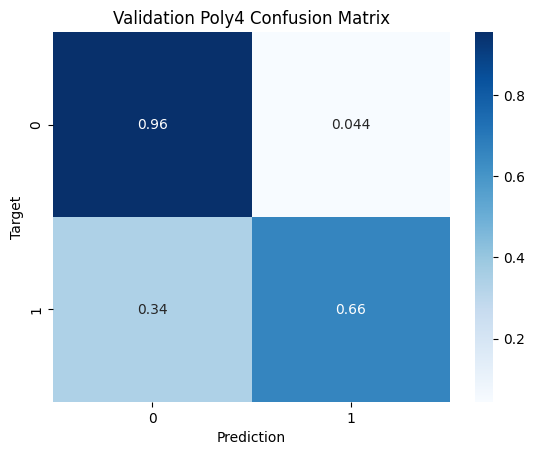

In [7]:
numeric_transformer_poly4 = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=4, include_bias=False)),
    ('scaler', MinMaxScaler())
])

preprocessor_poly4 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly4, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

pipeline_poly4 = Pipeline(steps=[
    ('preprocessor', preprocessor_poly4),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42))
])

pipeline_poly4.fit(train_inputs, train_targets)

train_preds_poly4 = predict_and_plot(pipeline_poly4, train_inputs, train_targets, 'Train Poly4')
val_preds_poly4 = predict_and_plot(pipeline_poly4, val_inputs, val_targets, 'Validation Poly4')

In [9]:
n_features = pipeline_poly4.named_steps['preprocessor'].transformers_[0][1].named_steps['poly'].n_output_features_
print(f"Кількість ознак після PolynomialFeatures(degree=4): {n_features}")

Кількість ознак після PolynomialFeatures(degree=4): 494


При степені 4 створено 494 ознаки. Є підозра на перенавчання моделі. Тому я обираю модель з завдання 2.

In [11]:
test_raw_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/test.csv')

test_probs2 = pipeline_poly2.predict_proba(test_raw_df)[:, 1]
test_probs4 = pipeline_poly4.predict_proba(test_raw_df)[:, 1]

submission_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/sample_submission.csv')

submission_df['Exited'] = test_probs2
submission_df.to_csv('/content/drive/MyDrive/Colab Notebooks/submission_poly_2.csv', index=False)
submission_df['Exited'] = test_probs4
submission_df.to_csv('/content/drive/MyDrive/Colab Notebooks/submission_poly_4.csv', index=False)

**Завдання 4. Перенавчання і регуляризація**.

  Скачайте набір даних `regression_data.csv`. Звичайте набір даних з `regression_data.csv`, розбийте на train і test (в тест 20%) і натренуйте модель лінійної регресії з масштабуванням числових ознак і поліноміальними ознаками до степені **5 включно**.

  Виміряйте якість прогностичної моделі і зробіть висновок, чи модель хороша, чи вона добре генералізує?


In [16]:
df_reg = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/regression_data.csv')

X = df_reg.drop('target', axis=1)
y = df_reg['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

poly_model = Pipeline([
    ('poly', PolynomialFeatures(degree=5, include_bias=False)),
    ('scaler', MinMaxScaler()),
    ('regressor', LinearRegression())
])

poly_model.fit(X_train, y_train)

def evaluate_regression(model, X, y, name=''):
    preds = model.predict(X)
    mse = mean_squared_error(y, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y, preds)
    print(f"{name}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2 Score: {r2:.4f}\n")

evaluate_regression(poly_model, X_train, y_train, 'Train')
evaluate_regression(poly_model, X_test, y_test, 'Test')

Train
RMSE: 0.0000
R2 Score: 1.0000

Test
RMSE: 12.3633
R2 Score: 0.9345



Модель погана. Перенавчання.Погано генералізує.

**Завдання 5**. Натренуйте моделі Lasso(), Ridge(), ElasaticNet() на цих даних (з поліном ознаками до степені 20 включно), порівняйте якість з тою, яка була отримана з лінійною регресією. Яка модель найкраще генералізує і чому на ваш погляд (можливо треба буде для відповіді зробити додатковий аналіз ознак)?

In [19]:
def train_and_evaluate_reg(model, name):
    pipeline = Pipeline([
        ('poly', PolynomialFeatures(degree=20, include_bias=False)),
        ('scaler', MinMaxScaler()),
        ('regressor', model)
    ])

    pipeline.fit(X_train, y_train)

    train_preds = pipeline.predict(X_train)
    test_preds = pipeline.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
    test_r2 = r2_score(y_test, test_preds)

    print(f"{name}")
    print(f"Train RMSE: {train_rmse:.4f}")
    print(f"Test RMSE:  {test_rmse:.4f}")
    print(f"Test R2 Score: {test_r2:.4f}\n")
    return pipeline

ridge_model = train_and_evaluate_reg(Ridge(alpha=1.0), "Ridge")
lasso_model = train_and_evaluate_reg(Lasso(alpha=1.0, max_iter=10000), "Lasso")
elastic_model = train_and_evaluate_reg(ElasticNet(alpha=0.1, l1_ratio=0.5), "ElasticNet")

Ridge
Train RMSE: 8.5978
Test RMSE:  76.5627
Test R2 Score: -1.5125

Lasso
Train RMSE: 5.0982
Test RMSE:  5.6719
Test R2 Score: 0.9862

ElasticNet
Train RMSE: 18.8100
Test RMSE:  124.9292
Test R2 Score: -5.6896



Найкраще генералізує Lasso. Мінімальна різниця між RMSE на тренувальних і тестових даних та велике значення R2.